<a href="https://colab.research.google.com/github/ilincabaiasu/IB9AU/blob/main/Required_Task_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Task 18

### Details

Load the file fraud_transactions.csv and create a synthetic data set of 5000 records.
Evaluate the quality of the synthetic data created.

Check the python notebook SD4 - Synthetic Loan Data Generation with CTGAN &
TVAE.ipynb for context and further details.

---



### What I found interesting

- Practical point of this exercise: real fraud transaction data contains sensitive personal and financial information, making it very difficult to share and therefore retreive for research => synthetic data that preserves the statistical properties of fraud patterns without exposing real individuals is valuable for model development and research / sharing between institutions
- Realistic specificities of this exercise: class imbalance is a core problem here, dataset has very few fraud cases relative to legitimate transactions


---



In [3]:
!pip install -q sdv ctgan
print("SDV and CTGAN installed.")

SDV and CTGAN installed.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.neighbors import NearestNeighbors
import os

print("Files in /content/:", os.listdir('/content/'))

df = pd.read_csv('/content/fraud_transactions.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Files in /content/: ['.config', 'fraud_transactions.csv', 'sample_data']
Shape: (6486, 8)
Columns: ['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender', 'state', 'job', 'is_fraud']


,trans_date_trans_time,merchant,category,amt,gender,state,job,is_fraud
0,2/27/19 21:32,"fraud_Langosh, Wintheiser and Hyatt",food_dining,83.64,F,TX,"Physicist, medical",0
1,2/13/19 19:41,fraud_Dibbert and Sons,entertainment,79.13,M,PA,Secretary/administrator,0
2,1/11/19 20:03,"fraud_McDermott, Osinski and Morar",home,12.02,F,CA,"Buyer, industrial",0
3,1/20/19 9:08,fraud_Bauch-Raynor,grocery_pos,84.41,M,TN,Clothing/textile technologist,0
4,1/4/19 17:04,"fraud_Reichert, Huels and Hoppe",shopping_net,2.81,F,ME,Financial trader,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6486 entries, 0 to 6485
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  6486 non-null   object 
 1   merchant               6486 non-null   object 
 2   category               6486 non-null   object 
 3   amt                    6486 non-null   float64
 4   gender                 6486 non-null   object 
 5   state                  6486 non-null   object 
 6   job                    6486 non-null   object 
 7   is_fraud               6486 non-null   int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 405.5+ KB


In [6]:
df.describe()

,amt,is_fraud
count,6486.000000,6486.000000
mean,101.700956,0.074931
std,189.292632,0.263300
min,1.000000,0.000000
25%,12.572500,0.000000
50%,52.080000,0.000000
75%,91.945000,0.000000
max,2312.210000,1.000000


In [7]:
possible_targets = [c for c in df.columns if any(
    kw in c.lower() for kw in ['fraud', 'label', 'target', 'class', 'is_fraud']
)]
print("Candidate target columns:", possible_targets)

TARGET_COL = possible_targets[0] if possible_targets else df.columns[-1]
print(f"Using target column: '{TARGET_COL}'")

print(f"\nClass distribution:")
print(df[TARGET_COL].value_counts(normalize=True))

Candidate target columns: ['is_fraud']
Using target column: 'is_fraud'

Class distribution:
is_fraud
0    0.925069
1    0.074931
Name: proportion, dtype: float64


### Preprocessing (identifying column types)

In [8]:
# Drop rows with nulls
df = df.dropna().reset_index(drop=True)

# Identify column types automatically
cat_cols = [c for c in df.columns
            if df[c].dtype == 'object' and c != TARGET_COL]

num_cols = [c for c in df.columns
            if df[c].dtype in ['int64', 'float64']
            and c != TARGET_COL
            and df[c].nunique() > 10]   # exclude low-cardinality ints

# Low-cardinality integer columns treated as discrete
discrete_int_cols = [c for c in df.columns
                     if df[c].dtype in ['int64', 'float64']
                     and c != TARGET_COL
                     and df[c].nunique() <= 10]

discrete_cols = cat_cols + discrete_int_cols + [TARGET_COL]

print(f"Categorical columns  : {cat_cols}")
print(f"Numerical columns    : {num_cols}")
print(f"Discrete int columns : {discrete_int_cols}")
print(f"Target               : {TARGET_COL}")
print(f"Total discrete cols for CTGAN: {discrete_cols}")

Categorical columns  : ['trans_date_trans_time', 'merchant', 'category', 'gender', 'state', 'job']
Numerical columns    : ['amt']
Discrete int columns : []
Target               : is_fraud
Total discrete cols for CTGAN: ['trans_date_trans_time', 'merchant', 'category', 'gender', 'state', 'job', 'is_fraud']


In [9]:
# Train/test split on real data for utility evaluation
real_train, real_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[TARGET_COL]
)
print(f"Real train: {real_train.shape}  |  Real test: {real_test.shape}")

Real train: (5188, 8)  |  Real test: (1298, 8)


### Train CTGAN & Generate 5,000 Synthetic Records

In [10]:
from ctgan import CTGAN

ctgan_cols = cat_cols + num_cols + [TARGET_COL]
ctgan_data = df[ctgan_cols].copy()

ctgan = CTGAN(
    epochs=300,
    batch_size=500,
    verbose=True
)

print("⏳ Training CTGAN...")
ctgan.fit(ctgan_data, discrete_columns=discrete_cols)
print("✅ CTGAN training complete.")

⏳ Training CTGAN...


Gen. (+00.00) | Discrim. (+00.00):   0%|          | 0/300 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Gen. (+00.94) | Discrim. (-00.04): 100%|██████████| 300/300 [16:21<00:00,  3.27s/it]

✅ CTGAN training complete.


In [11]:
N_SYNTH = 5000

synthetic_ctgan = ctgan.sample(N_SYNTH)
print(f"Generated {len(synthetic_ctgan)} synthetic records.")
synthetic_ctgan.head()

Generated 5000 synthetic records.


,trans_date_trans_time,merchant,category,gender,state,job,amt,is_fraud
0,2/25/19 20:34,fraud_Hudson-Ratke,gas_transport,M,MI,Systems analyst,61.296459,0
1,1/15/19 12:45,fraud_Berge LLC,personal_care,M,OK,Radio broadcast assistant,89.720391,0
2,2/11/19 23:08,fraud_Schimmel-Olson,gas_transport,F,AL,Trade mark attorney,74.666939,0
3,2/3/19 6:23,"fraud_Osinski, Ledner and Leuschke",kids_pets,F,MT,"Administrator, local government",8.424482,0
4,2/22/19 5:51,fraud_Stracke-Lemke,gas_transport,M,MI,"Engineer, production",58.190922,0


In [12]:
print("Real fraud distribution:")
print(df[TARGET_COL].value_counts(normalize=True))

print("\nCTGAN synthetic fraud distribution:")
print(synthetic_ctgan[TARGET_COL].value_counts(normalize=True))

Real fraud distribution:
is_fraud
0    0.925069
1    0.074931
Name: proportion, dtype: float64

CTGAN synthetic fraud distribution:
is_fraud
0    0.906
1    0.094
Name: proportion, dtype: float64


### Train TVAE & Generate 5,000 Synthetic Records

In [13]:
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata

tvae_data = df[ctgan_cols].copy()

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(tvae_data)

# Mark discrete columns explicitly
for col in discrete_cols:
    if col in tvae_data.columns:
        metadata.update_column(column_name=col, sdtype='categorical')

tvae = TVAESynthesizer(
    metadata=metadata,
    epochs=300,
    batch_size=500
)

print("⏳ Training TVAE...")
tvae.fit(tvae_data)
print("✅ TVAE training complete.")

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


⏳ Training TVAE...
✅ TVAE training complete.


In [14]:
synthetic_tvae = tvae.sample(N_SYNTH)
print(f"Generated {len(synthetic_tvae)} synthetic records (TVAE).")

print("\nTVAE synthetic fraud distribution:")
print(synthetic_tvae[TARGET_COL].value_counts(normalize=True))

Generated 5000 synthetic records (TVAE).

TVAE synthetic fraud distribution:
is_fraud
0    0.9422
1    0.0578
Name: proportion, dtype: float64


### Quality Evaluation

Fidelity - Kolmogorov-Smirnov Test (per numeric column)

In [15]:
def ks_per_feature(real_df, syn_df, cols):
    results = {}
    for col in cols:
        r = real_df[col].sample(min(5000, len(real_df)), random_state=42)
        s = syn_df[col].sample(min(5000, len(syn_df)), random_state=42)
        stat, pval = ks_2samp(r, s)
        results[col] = {'ks_stat': round(stat, 4), 'p_value': round(pval, 4)}
    return pd.DataFrame(results).T.sort_values('ks_stat')

ks_ctgan = ks_per_feature(df, synthetic_ctgan, num_cols)
ks_tvae  = ks_per_feature(df, synthetic_tvae,  num_cols)

ks_compare = pd.DataFrame({
    'KS_CTGAN': ks_ctgan['ks_stat'],
    'KS_TVAE' : ks_tvae['ks_stat']
}).sort_values('KS_CTGAN')

print("KS Statistics (lower = better fidelity):")
display(ks_compare)

print(f"\nMean KS — CTGAN: {ks_compare['KS_CTGAN'].mean():.4f}")
print(f"Mean KS — TVAE : {ks_compare['KS_TVAE'].mean():.4f}")

KS Statistics (lower = better fidelity):


,KS_CTGAN,KS_TVAE
amt,0.1554,0.1996



Mean KS — CTGAN: 0.1554
Mean KS — TVAE : 0.1996


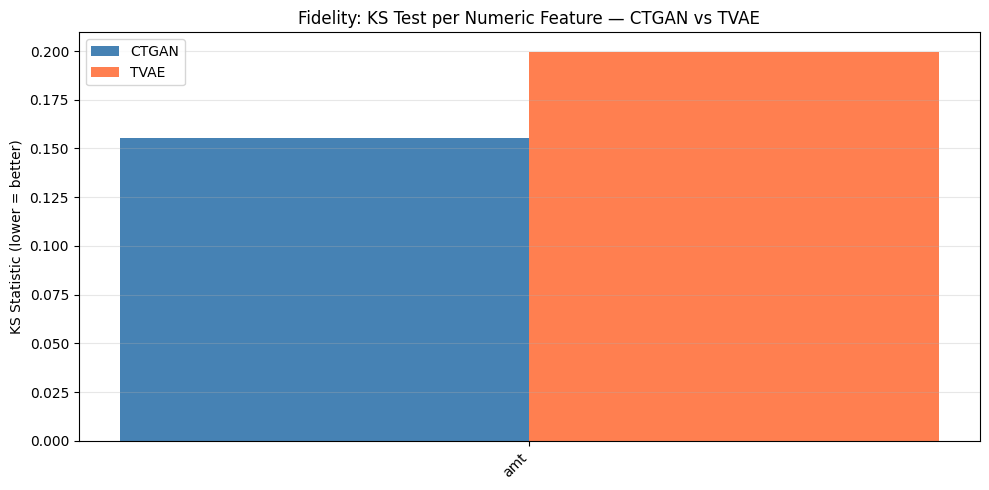

In [16]:
# Visualise KS comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ks_compare))
w = 0.35
ax.bar(x - w/2, ks_compare['KS_CTGAN'], w, label='CTGAN', color='steelblue')
ax.bar(x + w/2, ks_compare['KS_TVAE'],  w, label='TVAE',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(ks_compare.index, rotation=45, ha='right')
ax.set_ylabel('KS Statistic (lower = better)')
ax.set_title('Fidelity: KS Test per Numeric Feature — CTGAN vs TVAE')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ks_comparison.png', dpi=150)
plt.show()

Fidelity - Correlation Structure



In [17]:
if len(num_cols) >= 2:
    real_corr  = df[num_cols].corr()
    ctgan_corr = synthetic_ctgan[num_cols].corr()
    tvae_corr  = synthetic_tvae[num_cols].corr()

    corr_compare = pd.DataFrame({
        'mean_abs_diff_CTGAN': (real_corr - ctgan_corr).abs().mean(),
        'mean_abs_diff_TVAE' : (real_corr - tvae_corr).abs().mean()
    }).sort_values('mean_abs_diff_CTGAN')

    print("Mean absolute correlation difference (lower = better):")
    display(corr_compare)

    # Heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, corr, title in zip(
        axes,
        [real_corr, ctgan_corr, tvae_corr],
        ['Real', 'CTGAN Synthetic', 'TVAE Synthetic']
    ):
        sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0,
                    annot=len(num_cols) <= 8, fmt='.2f', linewidths=0.5)
        ax.set_title(f'Correlation — {title}')
    plt.tight_layout()
    plt.savefig('correlation_heatmaps.png', dpi=150)
    plt.show()
else:
    print("Not enough numeric columns for correlation analysis.")

Not enough numeric columns for correlation analysis.


Utility - TSTR vs Real Baseline

In [18]:
# Fit encoders on real training data only
ohe    = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

if cat_cols:
    ohe.fit(real_train[cat_cols])
scaler.fit(real_train[num_cols])

def preprocess(df_subset):
    parts = []
    if cat_cols:
        parts.append(ohe.transform(df_subset[cat_cols]))
    if num_cols:
        parts.append(scaler.transform(df_subset[num_cols]))
    X = np.hstack(parts) if parts else np.array([])
    y = df_subset[TARGET_COL].astype(int).values
    return X, y

print("✅ Encoders fitted on real training data.")

✅ Encoders fitted on real training data.


In [19]:
X_real_train, y_real_train = preprocess(real_train)
X_real_test,  y_real_test  = preprocess(real_test)

def train_and_evaluate(X_train, y_train, X_test, y_test, label):
    rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_proba = rf.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)
    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    print(f"  {label:35s} → AUC: {auc:.4f}  F1: {f1:.4f}")
    return auc, f1

print("Utility Evaluation (TSTR vs TRTR):")
auc_real,  f1_real  = train_and_evaluate(X_real_train, y_real_train,
                                          X_real_test,  y_real_test,
                                          'Train REAL, Test REAL')

X_ctgan, y_ctgan = preprocess(synthetic_ctgan)
auc_ctgan, f1_ctgan = train_and_evaluate(X_ctgan, y_ctgan,
                                          X_real_test, y_real_test,
                                          'Train CTGAN, Test REAL')

X_tvae, y_tvae = preprocess(synthetic_tvae)
auc_tvae, f1_tvae = train_and_evaluate(X_tvae, y_tvae,
                                        X_real_test, y_real_test,
                                        'Train TVAE, Test REAL')

Utility Evaluation (TSTR vs TRTR):
  Train REAL, Test REAL               → AUC: 0.9763  F1: 0.8276
  Train CTGAN, Test REAL              → AUC: 0.7896  F1: 0.4127
  Train TVAE, Test REAL               → AUC: 0.9396  F1: 0.1869


,AUC,F1
Train REAL,0.976347,0.827586
Train CTGAN,0.789608,0.412698
Train TVAE,0.939578,0.186916


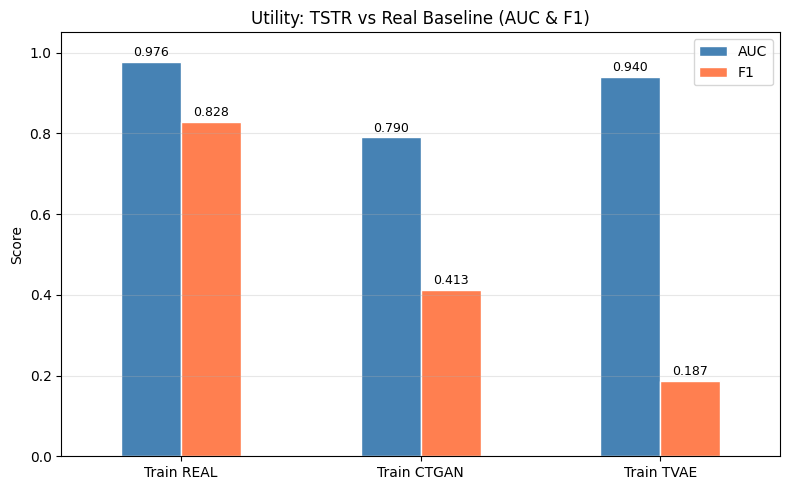

In [20]:
utility_df = pd.DataFrame({
    'AUC': [auc_real, auc_ctgan, auc_tvae],
    'F1' : [f1_real,  f1_ctgan,  f1_tvae]
}, index=['Train REAL', 'Train CTGAN', 'Train TVAE'])

display(utility_df)

# Plot
ax = utility_df.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'coral'],
                     edgecolor='white', rot=0)
ax.set_ylim(0, 1.05)
ax.set_title('Utility: TSTR vs Real Baseline (AUC & F1)')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=2)
plt.tight_layout()
plt.savefig('utility_comparison.png', dpi=150)
plt.show()

Privacy — Nearest-Neighbour Distance (Memorisation Check)

In [21]:
real_num  = df[num_cols].sample(min(5000, len(df)), random_state=42)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(real_num)

# CTGAN distances
syn_ctgan_num = synthetic_ctgan[num_cols].sample(min(5000, len(synthetic_ctgan)), random_state=42)
dist_ctgan, _ = nn.kneighbors(syn_ctgan_num)

# TVAE distances
syn_tvae_num = synthetic_tvae[num_cols].sample(min(5000, len(synthetic_tvae)), random_state=42)
dist_tvae, _ = nn.kneighbors(syn_tvae_num)

privacy_df = pd.DataFrame({
    'CTGAN_nn_dist': dist_ctgan.flatten(),
    'TVAE_nn_dist' : dist_tvae.flatten()
})

print("Nearest-Neighbour Distance Summary (higher = less memorisation risk):")
display(privacy_df.describe())

Nearest-Neighbour Distance Summary (higher = less memorisation risk):


,CTGAN_nn_dist,TVAE_nn_dist
count,5000.000000,5000.000000
mean,0.133026,0.193438
std,0.590113,1.815522
min,0.000001,0.000000
25%,0.004072,0.000000
50%,0.011092,0.010000
75%,0.031399,0.030000
max,14.886428,77.440000


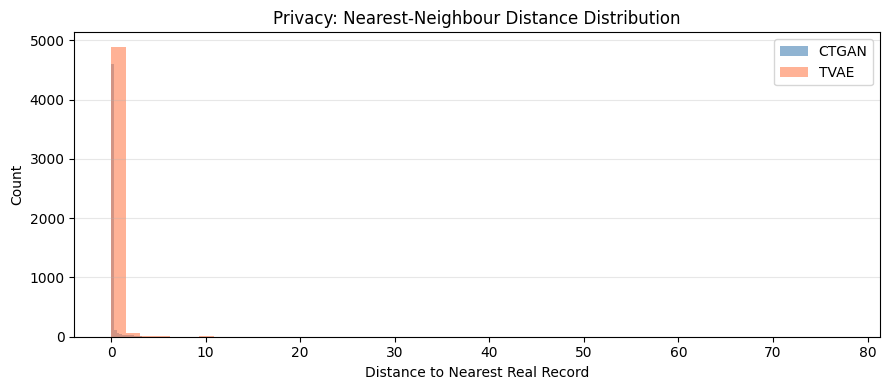

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(dist_ctgan.flatten(), bins=50, alpha=0.6, label='CTGAN', color='steelblue')
ax.hist(dist_tvae.flatten(),  bins=50, alpha=0.6, label='TVAE',  color='coral')
ax.set_xlabel('Distance to Nearest Real Record')
ax.set_ylabel('Count')
ax.set_title('Privacy: Nearest-Neighbour Distance Distribution')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('privacy_nn_distances.png', dpi=150)
plt.show()

Summary

In [23]:
from IPython.display import display, Markdown

summary = pd.DataFrame({
    'Mean KS (Fidelity ↓)' : [
        round(ks_compare['KS_CTGAN'].mean(), 4),
        round(ks_compare['KS_TVAE'].mean(),  4)
    ],
    'AUC — TSTR (Utility ↑)': [round(auc_ctgan, 4), round(auc_tvae, 4)],
    'F1  — TSTR (Utility ↑)': [round(f1_ctgan,  4), round(f1_tvae,  4)],
    'Median NN Dist (Privacy ↑)': [
        round(float(np.median(dist_ctgan)), 4),
        round(float(np.median(dist_tvae)),  4)
    ]
}, index=['CTGAN', 'TVAE'])

display(Markdown("## Quality Evaluation Summary"))
display(summary)
display(Markdown(f"""
**Real baseline (TRTR):** AUC = {auc_real:.4f}, F1 = {f1_real:.4f}

### Interpretation

**Fidelity (KS):** Lower KS statistic means the synthetic distribution is closer to the real one.
A KS < 0.1 per feature indicates excellent fidelity.

**Utility (TSTR):** AUC and F1 close to the real-trained baseline indicate the synthetic data
preserves the predictive signal needed to detect fraud. A TSTR AUC within 0.05 of TRTR is considered good.

**Privacy (NN Distance):** Higher median nearest-neighbour distances indicate the model is
generating genuinely novel records rather than memorising real transactions.
Very small distances (< 1e-4 after scaling) would suggest memorisation risk.
"""))

## Quality Evaluation Summary

,Mean KS (Fidelity ↓),AUC — TSTR (Utility ↑),F1 — TSTR (Utility ↑),Median NN Dist (Privacy ↑)
CTGAN,0.1554,0.7896,0.4127,0.0111
TVAE,0.1996,0.9396,0.1869,0.0100



**Real baseline (TRTR):** AUC = 0.9763, F1 = 0.8276

### Interpretation

**Fidelity (KS):** Lower KS statistic means the synthetic distribution is closer to the real one.
A KS < 0.1 per feature indicates excellent fidelity.

**Utility (TSTR):** AUC and F1 close to the real-trained baseline indicate the synthetic data
preserves the predictive signal needed to detect fraud. A TSTR AUC within 0.05 of TRTR is considered good.

**Privacy (NN Distance):** Higher median nearest-neighbour distances indicate the model is
generating genuinely novel records rather than memorising real transactions.
Very small distances (< 1e-4 after scaling) would suggest memorisation risk.
